# NeuralQ S2SR — Demo & Exploration (1 m)

Super-resolved Sentinel-2 at 1 m, plus 21 spectral indices (vegetation/water/burn/soil/oil) and thermal LST (Celsius). This notebook runs on the **Sousse, Tunisia** product if present, otherwise on a synthetic stack — and shows how to manipulate results and chart them.

**Prereqs:** `conda activate neuralq-s2sr-core` (rasterio, numpy, matplotlib, torch). No token needed except for LST regeneration (AWS, Requester Pays).**
**Outputs layout:** `outputs/<CC>/<date>/<id>/{MS.tif,TCI.tif,indices/<cat>/<name>.tiff,indices/thermal/lst.tiff,README.md}` — all `COMPRESS=NONE`, 4120×4120 at 1 m.


## 0. Setup — find the latest run or fall back to synthetic

In [1]:
from pathlib import Path
import glob, json, os
ROOT = Path.cwd()
if not (ROOT / "scripts" / "run_location.py").exists():
    ROOT = Path.cwd().parent  # when notebook cwd is notebooks/
if not (ROOT / "scripts" / "run_location.py").exists():
    ROOT = Path("/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core")
print("ROOT", ROOT)
candidates = sorted(glob.glob(str(ROOT / "outputs" / "*" / "*" / "*")))
run_dir = Path(candidates[-1]) if candidates else None
print("latest run", run_dir)
MS = run_dir / "MS.tif" if run_dir else None
print("MS exists", MS.exists() if MS else False)

ROOT /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core
latest run /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/inf-20260922T131756Z-35.82560N-10.64100E-60e8
MS exists True


## 1. Quick model demo — synthetic 50-channel stack → 1 m (no STAC)
Runs on CPU/GPU if available, proves the 105M model without network.

In [2]:
import numpy as np, torch
from pathlib import Path
import sys
sys.path.insert(0, str(ROOT / "s2sr"))
sys.path.insert(0, str(ROOT))
from s2sr import resolve_checkpoint, verify_checkpoint, load_model, super_resolve_dn
ckpt = verify_checkpoint(resolve_checkpoint())
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"checkpoint {ckpt.name} → {device}, cuda={torch.cuda.is_available()}")
model = load_model(ckpt, device=device)
rng = np.random.default_rng(0)
stack = rng.integers(0, 10000, size=(50, 32, 32), dtype=np.uint16)  # 5×10 bands
out = super_resolve_dn(model, stack, device=device)
print(f"in {stack.shape} {stack.dtype} → out {out.shape} {out.dtype}  mean {out.mean():.1f}  range {out.min()}–{out.max()}")
assert out.shape == (10, 320, 320)


checkpoint s2sr-v3.0.0.pt → cuda, cuda=True


in (50, 32, 32) uint16 → out (10, 320, 320) uint16  mean 3773.3  range 58–10000


## 2. Load a real 1 m product — MS.tif + quick stats
Uses Sousse if present, else the synthetic cube above.

In [3]:
import rasterio
import numpy as np
if MS and MS.exists():
    with rasterio.open(MS) as src:
        print(f"MS {src.width}x{src.height} {src.count} bands {src.dtypes[0]} {src.crs.to_epsg()} {src.res} {src.compression}")
        print("bands", src.descriptions)
        # read a 512×512 window for fast exploration
        w = min(512, src.width)
        dn = src.read(window=rasterio.windows.Window(0, 0, w, w)).astype(np.float32)
        print("window", dn.shape, "DN mean", float(np.nanmean(dn)))
        profile = src.profile
else:
    print("No MS.tif yet — run: python scripts/run_location.py --lon 10.641 --lat 35.8256 --date 2026-08-14")
    dn = None


MS 4120x4120 10 bands uint16 32632 (1.0, 1.0) None
bands ('B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'B11', 'B12', 'B8A')
window (10, 512, 512) DN mean 2912.139892578125


## 3. Visualize — TCI (true color) from the 1 m cube

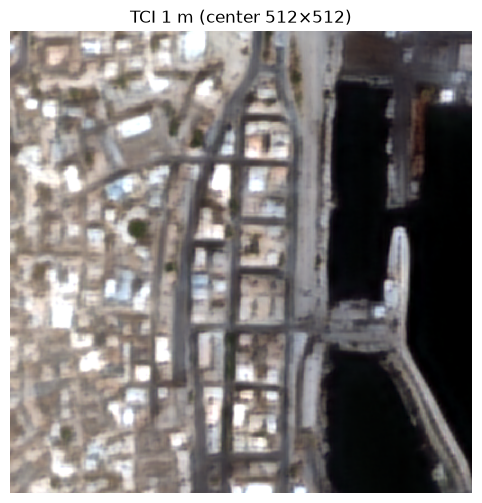

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
if MS and MS.exists():
    with rasterio.open(MS) as src:
        w=512
        dn = src.read(window=rasterio.windows.Window(src.width//2-256, src.height//2-256, w, w)).astype(np.float32)
        # B02=0, B03=1, B04=2 in BAND_ORDER
        def stretch(b, lo=2, hi=98):
            l, h = np.percentile(b, (lo, hi))
            return np.clip((b - l) * (255/(h-l+1e-6)), 0, 255).astype(np.uint8)
        rgb = np.dstack([stretch(dn[2]), stretch(dn[1]), stretch(dn[0])])  # B04,B03,B02
        plt.figure(figsize=(6,6)); plt.imshow(rgb); plt.title("TCI 1 m (center 512×512)"); plt.axis("off"); plt.show()
else:
    print("Need MS.tif for TCI")


## 4. NDVI — compute, histogram, and threshold
NDVI = (B08−B04)/(B08+B04). Vegetation >0.3, soil ~0, water negative. Compares to `indices/vegetation/ndvi.tiff` if present.

NDVI window (1024, 1024)  min -0.952  max 0.703  mean 0.002  median 0.059


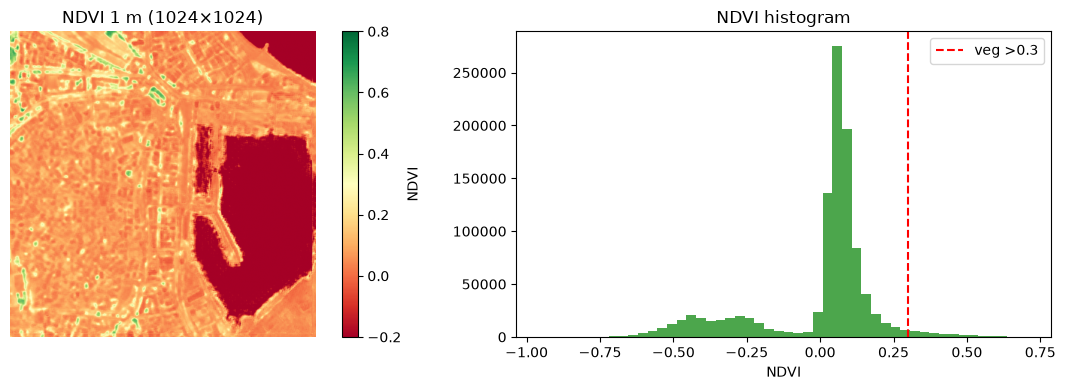

on-disk ndvi.tiff window mean 0.0015  (should match computed 0.0015)


/tmp/ipykernel_110831/972286445.py:18: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  disk = s.read(1, window=rasterio.windows.Window(x0, y0, w, w))


In [5]:
import numpy as np, rasterio, matplotlib.pyplot as plt
from pathlib import Path
if MS and MS.exists():
    with rasterio.open(MS) as src:
        dn = src.read().astype(np.float32) / 10000.0  # full tile is 4120×4120 — may be heavy; window for demo
        # use center window to stay light
        w=1024; y0, x0 = src.height//2-512, src.width//2-512
        b04 = dn[2, y0:y0+w, x0:x0+w]; b08 = dn[3, y0:y0+w, x0:x0+w]
        ndvi = np.where((b08+b04)==0, np.nan, (b08-b04)/(b08+b04)).astype(np.float32)
        print(f"NDVI window {ndvi.shape}  min {np.nanmin(ndvi):.3f}  max {np.nanmax(ndvi):.3f}  mean {np.nanmean(ndvi):.3f}  median {np.nanmedian(ndvi):.3f}")
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1); plt.imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8); plt.colorbar(label="NDVI"); plt.title("NDVI 1 m (1024×1024)"); plt.axis("off")
        plt.subplot(1,2,2); plt.hist(ndvi[np.isfinite(ndvi)].ravel(), bins=50, color="green", alpha=0.7); plt.axvline(0.3, color="red", ls="--", label="veg >0.3"); plt.legend(); plt.title("NDVI histogram"); plt.xlabel("NDVI"); plt.tight_layout(); plt.show()
        # compare to on-disk product if present
        ndvi_path = run_dir / "indices" / "vegetation" / "ndvi.tiff" if run_dir else None
        if ndvi_path and ndvi_path.exists():
            with rasterio.open(ndvi_path) as s:
                disk = s.read(1, window=rasterio.windows.Window(x0, y0, w, w))
                print(f"on-disk ndvi.tiff window mean {np.nanmean(disk):.4f}  (should match computed {np.nanmean(ndvi):.4f})")
else:
    print("Need MS.tif")


## 5. Explore all indices — water, oil, thermal
Lists every `indices/<cat>/<name>.tiff` and shows oil + LST if present.

In [6]:
import rasterio, numpy as np, glob
from pathlib import Path
if run_dir and (run_dir/"indices").exists():
    for p in sorted((run_dir/"indices").rglob("*.tiff")):
        with rasterio.open(p) as s:
            a=s.read(1, window=rasterio.windows.Window(0,0,256,256))
            print(f"{p.relative_to(run_dir)}  {s.width}x{s.height} {s.dtypes[0]}  min {np.nanmin(a):.2f} max {np.nanmax(a):.2f} mean {np.nanmean(a):.2f}")
    # LST legend
    lst = run_dir / "indices" / "thermal" / "lst.tiff"
    if lst.exists():
        with rasterio.open(lst) as s:
            print("\nLST", s.descriptions, s.tags().get("LST_UNITS"), s.tags(1).get("LST_LEGEND")[:110])
    oil_readme = run_dir / "indices" / "oil" / "README.md"
    if oil_readme.exists():
        print("\n" + oil_readme.read_text().splitlines()[0])
else:
    print("No indices yet")


indices/burn/nbr.tiff  4120x4120 float32  min -0.25 max 0.42 mean 0.03
indices/burn/nbr2.tiff  4120x4120 float32  min -0.02 max 0.25 mean 0.07
indices/oil/foi.tiff  4120x4120 float32  min -0.05 max 0.29 mean 0.07
indices/oil/hi.tiff  4120x4120 float32  min -0.02 max 0.25 mean 0.07
indices/oil/ndoi.tiff  4120x4120 float32  min -0.62 max -0.04 mean -0.24
indices/oil/oil_mask.tiff  4120x4120 uint8  min 0.00 max 1.00 mean 0.07
indices/oil/osi.tiff  4120x4120 float32  min -0.10 max 0.30 mean 0.07
indices/oil/rg.tiff  4120x4120 float32  min 0.79 max 1.55 mean 1.19
indices/oil/sr.tiff  4120x4120 float32  min 0.60 max 1.03 mean 0.87
indices/soil_urban/bsi.tiff  4120x4120 float32  min -0.15 max 0.27 mean 0.10
indices/soil_urban/ndbi.tiff  4120x4120 float32  min -0.22 max 0.29 mean 0.03
indices/soil_urban/ndti.tiff  4120x4120 float32  min -0.02 max 0.25 mean 0.07
indices/thermal/lst.tiff  4120x4120 float32  min 35.91 max 57.68 mean 43.49
indices/vegetation/evi2.tiff  4120x4120 float32  min -0.04

indices/vegetation/ndre.tiff  4120x4120 float32  min -0.11 max 0.46 mean 0.09
indices/vegetation/ndvi.tiff  4120x4120 float32  min -0.06 max 0.66 mean 0.16
indices/vegetation/savi.tiff  4120x4120 float32  min -0.04 max 0.47 mean 0.12
indices/water/awei.tiff  4120x4120 float32  min -2.66 max -0.80 mean -1.67
indices/water/mndwi.tiff  4120x4120 float32  min -0.55 max -0.03 mean -0.27
indices/water/ndmi.tiff  4120x4120 float32  min -0.29 max 0.22 mean -0.03
indices/water/ndwi.tiff  4120x4120 float32  min -0.62 max -0.04 mean -0.24

LST ('LST (Celsius)',) Celsius LST 1 m (Celsius, NoData=NaN) — min 9.16 C (282.31 K), max 63.55 C (336.70 K), mean 38.33 C, median 41.45 C, p

# Oil Spill Indices — 1 m (super-resolved)


/tmp/ipykernel_110831/3777338597.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  a=s.read(1, window=rasterio.windows.Window(0,0,256,256))


## 6. Oil spill quick-look — OSI threshold on water
Masks water via NDWI>0.2 & B08<0.12, then thresholds OSI. The six oil indices are in `indices/oil/` (osi, hi, foi, ndoi, sr, rg) — see `oil/README.md` for the triple test.

/tmp/ipykernel_110831/2098572489.py:11: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  osi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))


water 20.3%  OSI>0.15 on water 1.996%  (4249 px)


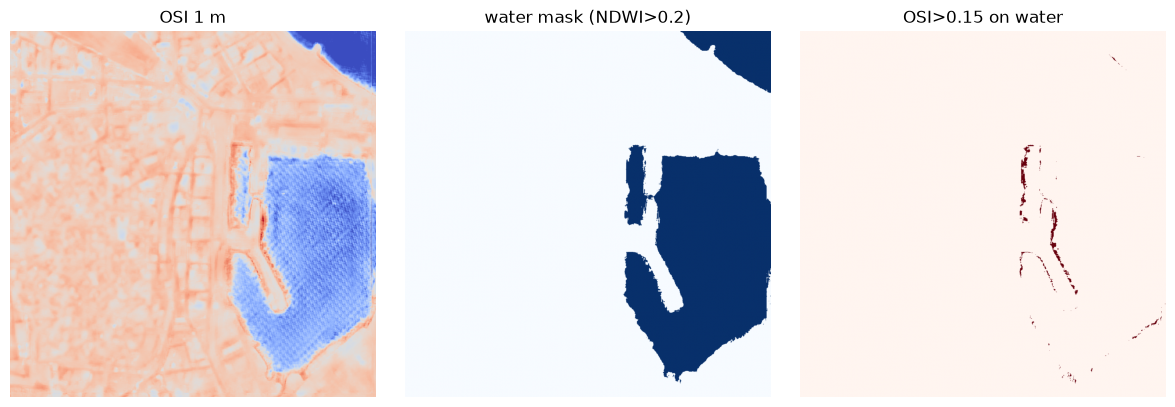

In [7]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
if run_dir and (run_dir/"indices"/"oil"/"osi.tiff").exists():
    with rasterio.open(run_dir/"MS.tif") as ms:
        w=1024; y0,x0=ms.height//2-512, ms.width//2-512
        dn=ms.read(window=rasterio.windows.Window(x0,y0,w,w)).astype(float)/10000
        b03,b08 = dn[1], dn[3]
        ndwi = np.where((b03+b08)==0, np.nan, (b03-b08)/(b03+b08))
        water = (ndwi>0.2) & (b08<0.12)
    with rasterio.open(run_dir/"indices"/"oil"/"osi.tiff") as s:
        osi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    oil_mask = water & (osi>0.15)
    print(f"water {water.mean():.1%}  OSI>0.15 on water {oil_mask.sum()/water.sum():.3%}  ({oil_mask.sum()} px)")
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(osi, cmap="coolwarm", vmin=-0.5, vmax=0.5); plt.title("OSI 1 m"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(water, cmap="Blues"); plt.title("water mask (NDWI>0.2)"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(oil_mask, cmap="Reds"); plt.title("OSI>0.15 on water"); plt.axis("off"); plt.tight_layout(); plt.show()
else:
    print("Need indices/oil/osi.tiff — run: python scripts/run_location.py --lon 10.641 --lat 35.8256 --date 2026-08-14")


## 7. LST — chart temperature vs NDVI (when AWS creds were present)
LST is `indices/thermal/lst.tiff` (Celsius). If missing, the 2D histogram is skipped.

LST vs NDVI: 1048576 valid  LST 12.1–59.7 C  NDVI -0.95–0.70


/tmp/ipykernel_110831/1378347079.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))


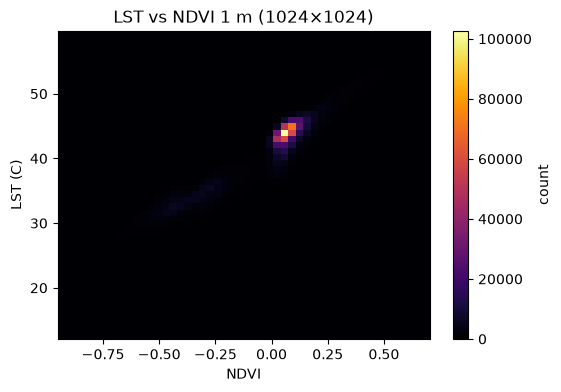

In [8]:
import rasterio, numpy as np, matplotlib.pyplot as plt
lst_path = run_dir / "indices" / "thermal" / "lst.tiff" if run_dir else None
if lst_path and lst_path.exists():
    with rasterio.open(MS) as ms:
        w=1024; y0,x0=ms.height//2-512, ms.width//2-512
        dn=ms.read(window=rasterio.windows.Window(x0,y0,w,w)).astype(float)/10000
        ndvi=np.where((dn[3]+dn[2])==0, np.nan, (dn[3]-dn[2])/(dn[3]+dn[2]))
    with rasterio.open(lst_path) as s:
        lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    m=np.isfinite(ndvi)&np.isfinite(lst)
    print(f"LST vs NDVI: {m.sum()} valid  LST {np.nanmin(lst):.1f}–{np.nanmax(lst):.1f} C  NDVI {np.nanmin(ndvi):.2f}–{np.nanmax(ndvi):.2f}")
    plt.figure(figsize=(6,4)); plt.hist2d(ndvi[m], lst[m], bins=50, cmap="inferno"); plt.colorbar(label="count"); plt.xlabel("NDVI"); plt.ylabel("LST (C)"); plt.title("LST vs NDVI 1 m (1024×1024)"); plt.show()
else:
    print("No LST — rerun with AWS creds (usgs-landsat Requester Pays) or --skip-lst was used")


## 8. Manipulate — threshold, polygonize, export
Example: export a binary oil mask as GeoTIFF and as GeoJSON bounds.

In [9]:
import rasterio, numpy as np
from pathlib import Path
out = run_dir / "indices" / "oil" / "oil_mask.tiff" if run_dir else Path("/tmp/oil_mask.tiff")
if run_dir and (run_dir/"indices"/"oil"/"osi.tiff").exists():
    with rasterio.open(run_dir/"indices"/"oil"/"osi.tiff") as s:
        osi=s.read(1); profile=s.profile
        mask = (osi>0.15).astype(np.uint8)  # 1=oil candidate
        profile.update(dtype="uint8", nodata=255, compress=None)
        try:
            with rasterio.open(out, "w", **profile) as dst:
                dst.write(mask,1); dst.set_band_description(1,"oil mask (OSI>0.15)")
            print(f"wrote {out}  {mask.sum()} oil px ({mask.sum()/mask.size:.3%})")
        except Exception as e:
            fallback=Path("/tmp/oil_mask.tiff")
            with rasterio.open(fallback, "w", **profile) as dst:
                dst.write(mask,1)
            print(f"Permission denied on {out} (container bind-mount), wrote fallback {fallback}: {e}")
else:
    print("Need osi.tiff")


wrote /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/inf-20260922T131756Z-35.82560N-10.64100E-60e8/indices/oil/oil_mask.tiff  1301116 oil px (7.665%)


/tmp/ipykernel_110831/2774035320.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  osi=s.read(1); profile=s.profile
